In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving tickets.csv to tickets.csv
User uploaded file "tickets.csv" with length 9201606 bytes


In [ ]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving business_units.csv to business_units.csv
Saving issue_categories.csv to issue_categories.csv
Saving processes.csv to processes.csv
Saving sla_targets.csv to sla_targets.csv
User uploaded file "business_units.csv" with length 175 bytes
User uploaded file "issue_categories.csv" with length 145 bytes
User uploaded file "processes.csv" with length 177 bytes
User uploaded file "sla_targets.csv" with length 56 bytes


In [ ]:
import pandas as pd

df = pd.read_csv("tickets.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 100000
Columns: 16


,Ticket_ID,Business_Unit_ID,Process_ID,Category_ID,Region,Priority,Created_Date,Resolution_Hours,SLA_Hours,SLA_Breached,Status,Root_Cause,Risk_Score,Risk_Category,Escalation_Flag,Customer_Impact
0,TKT-000001,8,6,1,UK,Medium,2024-05-30,58.9,72,No,Resolved,Human Error,20,Low,No,Low
1,TKT-000002,1,1,8,Australia,Low,2025-10-20,177.2,120,Yes,Closed,Missing Data,50,Medium,No,Low
2,TKT-000003,7,8,3,Singapore,Medium,2025-08-07,82.3,72,Yes,Closed,System Defect,56,Medium,Yes,Medium
3,TKT-000004,8,3,3,UK,Medium,2024-05-30,11.7,72,No,Resolved,External Dependency,29,Low,No,Low
4,TKT-000005,3,4,1,Canada,High,2025-03-24,25.8,24,Yes,Closed,Training Gap,56,Medium,Yes,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Ticket_ID         100000 non-null  object 
 1   Business_Unit_ID  100000 non-null  int64  
 2   Process_ID        100000 non-null  int64  
 3   Category_ID       100000 non-null  int64  
 4   Region            100000 non-null  object 
 5   Priority          100000 non-null  object 
 6   Created_Date      100000 non-null  object 
 7   Resolution_Hours  100000 non-null  float64
 8   SLA_Hours         100000 non-null  int64  
 9   SLA_Breached      100000 non-null  object 
 10  Status            100000 non-null  object 
 11  Root_Cause        98800 non-null   object 
 12  Risk_Score        100000 non-null  int64  
 13  Risk_Category     100000 non-null  object 
 14  Escalation_Flag   100000 non-null  object 
 15  Customer_Impact   71603 non-null   object 
dtypes: float64(1), int64(

In [ ]:
#convert datatypes
# Convert date column
df["Created_Date"] = pd.to_datetime(df["Created_Date"])

# Convert Boolean columns
df["SLA_Breached"] = df["SLA_Breached"].map({
    "True": True,
    "False": False
})

df["Escalation_Flag"] = df["Escalation_Flag"].map({
    "True": True,
    "False": False
})

# Check the updated data types
df.dtypes

,0
Ticket_ID,object
Business_Unit_ID,int64
Process_ID,int64
Category_ID,int64
Region,object
Priority,object
Created_Date,datetime64[ns]
Resolution_Hours,float64
SLA_Hours,int64
SLA_Breached,object


In [ ]:
print("SLA_Breached values:")
print(df["SLA_Breached"].value_counts(dropna=False))

print("\nEscalation_Flag values:")
print(df["Escalation_Flag"].value_counts(dropna=False))

SLA_Breached values:
SLA_Breached
NaN    100000
Name: count, dtype: int64

Escalation_Flag values:
Escalation_Flag
NaN    100000
Name: count, dtype: int64


In [ ]:
# Reload the original CSV to restore the columns
df = pd.read_csv("tickets.csv")

print("SLA_Breached:")
print(df["SLA_Breached"].value_counts(dropna=False))

print("\nEscalation_Flag:")
print(df["Escalation_Flag"].value_counts(dropna=False))

SLA_Breached:
SLA_Breached
No     69454
Yes    30546
Name: count, dtype: int64

Escalation_Flag:
Escalation_Flag
No     83140
Yes    16860
Name: count, dtype: int64


In [ ]:
# Convert date
df["Created_Date"] = pd.to_datetime(df["Created_Date"])

# Convert Yes/No columns to Boolean
df["SLA_Breached"] = df["SLA_Breached"].map({
    "Yes": True,
    "No": False
})

df["Escalation_Flag"] = df["Escalation_Flag"].map({
    "Yes": True,
    "No": False
})

# Check the result
print(df[["Created_Date", "SLA_Breached", "Escalation_Flag"]].dtypes)

Created_Date       datetime64[ns]
SLA_Breached                 bool
Escalation_Flag              bool
dtype: object


In [ ]:
#check missing values
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Values": missing,
    "Missing_Percentage": (missing / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Values"] > 0
].sort_values("Missing_Values", ascending=False)

missing_summary

,Missing_Values,Missing_Percentage
Customer_Impact,28397,28.4
Root_Cause,1200,1.2


In [ ]:
#filling missing categorical columns
df["Root_Cause_Clean"] = df["Root_Cause"].fillna("Unknown")
df["Customer_Impact_Clean"] = df["Customer_Impact"].fillna("Unknown")

# Check the result
print("Root Cause:")
print(df["Root_Cause_Clean"].value_counts())

print("\nCustomer Impact:")
print(df["Customer_Impact_Clean"].value_counts())

Root Cause:
Root_Cause_Clean
Unknown                13515
Process Gap            12522
External Dependency    12468
System Defect          12449
Missing Data           12307
Training Gap           12294
Integration Failure    12236
Human Error            12209
Name: count, dtype: int64

Customer Impact:
Customer_Impact_Clean
Low        31953
Unknown    28397
Medium     23678
High       12906
Severe      3066
Name: count, dtype: int64


In [ ]:
#Descriptive statistics
df[[
    "Resolution_Hours",
    "SLA_Hours",
    "Risk_Score"
]].describe().round(2)

,Resolution_Hours,SLA_Hours,Risk_Score
count,100000.00,100000.00,100000.00
mean,45.94,63.92,41.99
std,45.61,35.06,18.04
min,0.50,8.00,8.00
25%,18.70,24.00,28.00
50%,33.50,72.00,40.00
75%,57.10,72.00,54.00
max,720.00,120.00,90.00


In [ ]:
#Investigate resolution-time outliers
df["Resolution_Hours"].quantile([0.90, 0.95, 0.99, 0.995, 1.00])

,Resolution_Hours
0.900,92.600
0.950,125.300
0.990,235.201
0.995,286.000
1.000,720.000


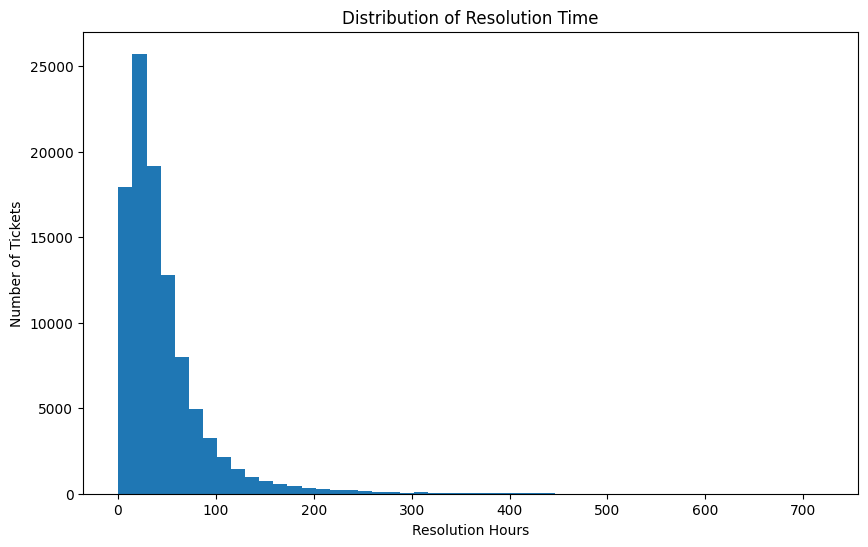

In [ ]:
#resolution-time distribution.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df["Resolution_Hours"], bins=50)

plt.title("Distribution of Resolution Time")
plt.xlabel("Resolution Hours")
plt.ylabel("Number of Tickets")

plt.show()

In [ ]:
#Compare resolution time by risk category
risk_resolution = (
    df.groupby("Risk_Category")["Resolution_Hours"]
      .agg(["count", "mean", "median"])
      .round(2)
)

risk_resolution

,count,mean,median
Risk_Category,,,
High,9078,40.03,31.6
Low,49938,39.55,33.0
Medium,40984,55.04,35.1


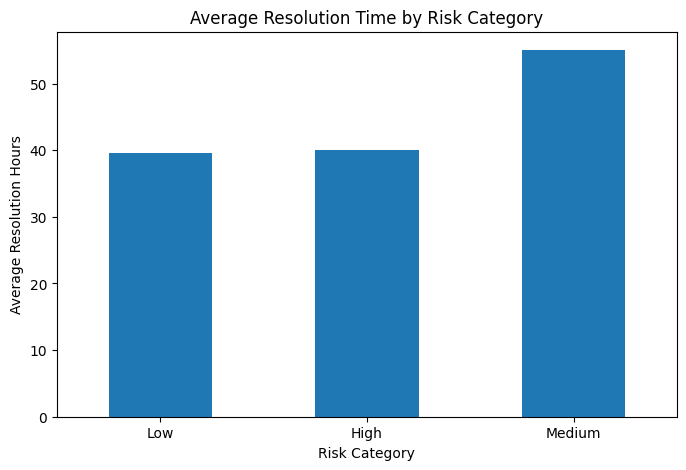

In [ ]:
#visualisation of resolution time by risk category
risk_resolution["mean"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Resolution Time by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Resolution Hours")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#Calculate SLA compliance by risk category
risk_sla = (
    df.groupby("Risk_Category")
      .agg(
          total_tickets=("Ticket_ID", "count"),
          sla_breaches=("SLA_Breached", "sum")
      )
)

risk_sla["sla_compliance_pct"] = (
    (1 - risk_sla["sla_breaches"] / risk_sla["total_tickets"]) * 100
).round(2)

risk_sla

,total_tickets,sla_breaches,sla_compliance_pct
Risk_Category,,,
High,9078,9032,0.51
Low,49938,1288,97.42
Medium,40984,20226,50.65


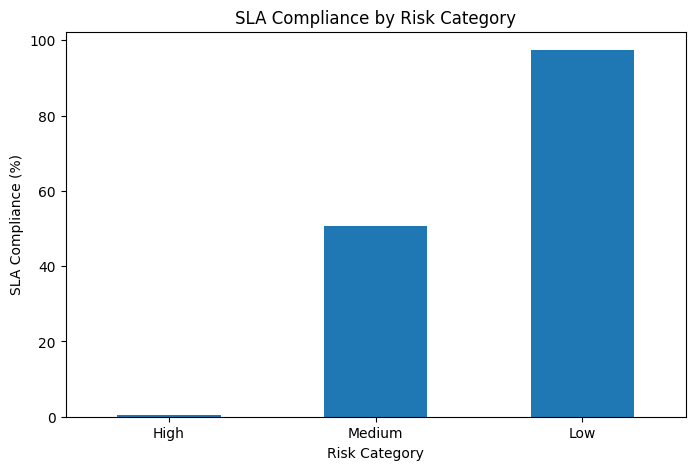

In [ ]:
#visualize SLA compliance by risk category
risk_sla["sla_compliance_pct"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("SLA Compliance by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("SLA Compliance (%)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#Analyze escalation vs resolution time
escalation_analysis = (
    df.groupby("Escalation_Flag")
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          avg_risk_score=("Risk_Score", "mean"),
          sla_breaches=("SLA_Breached", "sum")
      )
      .round(2)
)

escalation_analysis["sla_compliance_pct"] = (
    (1 - escalation_analysis["sla_breaches"] /
     escalation_analysis["total_tickets"]) * 100
).round(2)

escalation_analysis

,total_tickets,avg_resolution_hours,avg_risk_score,sla_breaches,sla_compliance_pct
Escalation_Flag,,,,,
False,83140,39.85,37.87,13686,83.54
True,16860,75.99,62.29,16860,0.00


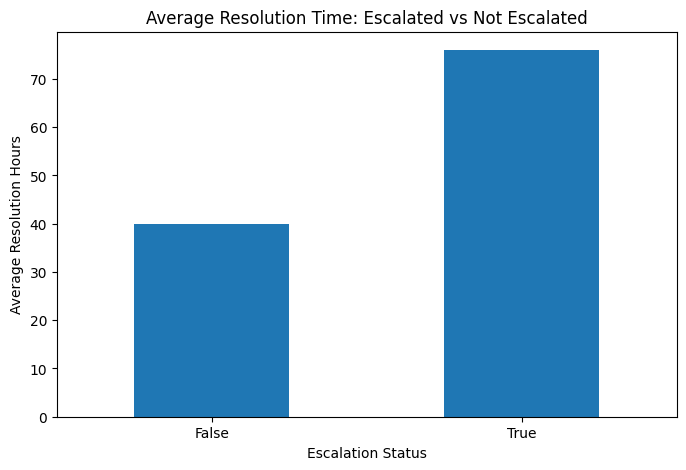

In [ ]:
#visualize escalation vs resolution time
escalation_analysis["avg_resolution_hours"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Resolution Time: Escalated vs Not Escalated")
plt.xlabel("Escalation Status")
plt.ylabel("Average Resolution Hours")
plt.xticks(rotation=0)

plt.show()

In [ ]:
#business unit analysis
business_unit_analysis = (
    df.groupby("Business_Unit_ID")
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          sla_breaches=("SLA_Breached", "sum"),
          avg_risk_score=("Risk_Score", "mean"),
          escalations=("Escalation_Flag", "sum")
      )
      .round(2)
)

business_unit_analysis["sla_compliance_pct"] = (
    (1 - business_unit_analysis["sla_breaches"] /
     business_unit_analysis["total_tickets"]) * 100
).round(2)

business_unit_analysis

,total_tickets,avg_resolution_hours,sla_breaches,avg_risk_score,escalations,sla_compliance_pct
Business_Unit_ID,,,,,,
1,12506,45.82,3890,42.11,2152,68.89
2,12462,46.35,3916,42.26,2136,68.58
3,12378,46.05,3750,41.92,2030,69.70
4,12734,45.38,3792,41.88,2089,70.22
5,12462,46.22,3882,42.12,2135,68.85
6,12562,46.34,3796,41.94,2122,69.78
7,12465,45.58,3745,41.81,2075,69.96
8,12431,45.79,3775,41.88,2121,69.63


In [ ]:
#Add business-unit names
business_unit_map = {
    1: "Customer Operations",
    2: "Quality Assurance",
    3: "Supply Chain",
    4: "Manufacturing",
    5: "Regulatory Affairs",
    6: "IT Operations",
    7: "Finance",
    8: "Commercial Operations"
}

business_unit_analysis = business_unit_analysis.reset_index()

business_unit_analysis["Business_Unit"] = (
    business_unit_analysis["Business_Unit_ID"].map(business_unit_map)
)

business_unit_analysis = business_unit_analysis[
    [
        "Business_Unit",
        "total_tickets",
        "avg_resolution_hours",
        "sla_compliance_pct",
        "avg_risk_score",
        "escalations"
    ]
].sort_values("sla_compliance_pct")

business_unit_analysis

,Business_Unit,total_tickets,avg_resolution_hours,sla_compliance_pct,avg_risk_score,escalations
1,Quality Assurance,12462,46.35,68.58,42.26,2136
4,Regulatory Affairs,12462,46.22,68.85,42.12,2135
0,Customer Operations,12506,45.82,68.89,42.11,2152
7,Commercial Operations,12431,45.79,69.63,41.88,2121
2,Supply Chain,12378,46.05,69.70,41.92,2030
5,IT Operations,12562,46.34,69.78,41.94,2122
6,Finance,12465,45.58,69.96,41.81,2075
3,Manufacturing,12734,45.38,70.22,41.88,2089


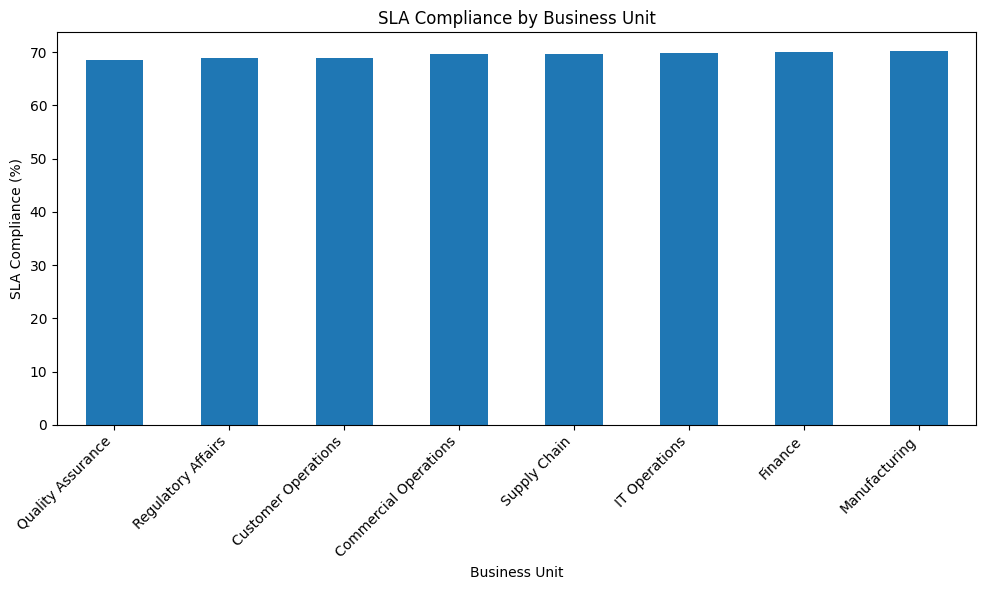

In [ ]:
#visualize SLA compliance by business unit.
business_unit_analysis.plot(
    x="Business_Unit",
    y="sla_compliance_pct",
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("SLA Compliance by Business Unit")
plt.xlabel("Business Unit")
plt.ylabel("SLA Compliance (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


In [ ]:
#Analyze SLA performance by priority
priority_analysis = (
    df.groupby("Priority")
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          sla_breaches=("SLA_Breached", "sum"),
          avg_risk_score=("Risk_Score", "mean"),
          escalations=("Escalation_Flag", "sum")
      )
      .round(2)
)

priority_analysis["sla_compliance_pct"] = (
    (1 - priority_analysis["sla_breaches"] /
     priority_analysis["total_tickets"]) * 100
).round(2)

priority_analysis

,total_tickets,avg_resolution_hours,sla_breaches,avg_risk_score,escalations,sla_compliance_pct
Priority,,,,,,
Critical,8042,22.38,6495,71.16,3610,19.24
High,23997,34.68,13004,55.85,7136,45.81
Low,17885,61.73,1794,25.05,991,89.97
Medium,50076,49.48,9253,36.71,5123,81.52


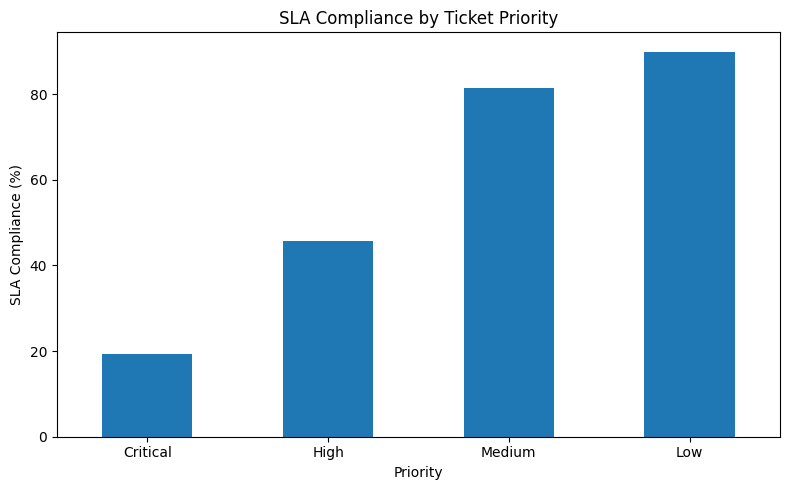

In [ ]:
#visualize  SLA performance by priority
priority_order = ["Critical", "High", "Medium", "Low"]

priority_analysis.loc[priority_order, "sla_compliance_pct"].plot(
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("SLA Compliance by Ticket Priority")
plt.xlabel("Priority")
plt.ylabel("SLA Compliance (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Analyze monthly performance
monthly_analysis = (
    df.groupby(df["Created_Date"].dt.to_period("M"))
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          sla_breaches=("SLA_Breached", "sum"),
          avg_risk_score=("Risk_Score", "mean")
      )
      .round(2)
)

monthly_analysis["sla_compliance_pct"] = (
    (1 - monthly_analysis["sla_breaches"] /
     monthly_analysis["total_tickets"]) * 100
).round(2)

monthly_analysis


,total_tickets,avg_resolution_hours,sla_breaches,avg_risk_score,sla_compliance_pct
Created_Date,,,,,
2024-01,4229,45.90,1256,41.43,70.30
2024-02,4026,47.11,1240,42.08,69.20
2024-03,4181,46.67,1275,41.91,69.50
2024-04,4132,45.64,1260,42.22,69.51
2024-05,4304,45.74,1322,42.03,69.28
2024-06,4055,45.97,1208,41.85,70.21
2024-07,4302,46.29,1343,41.94,68.78
2024-08,4112,45.71,1299,42.48,68.41
2024-09,3995,46.15,1206,42.14,69.81


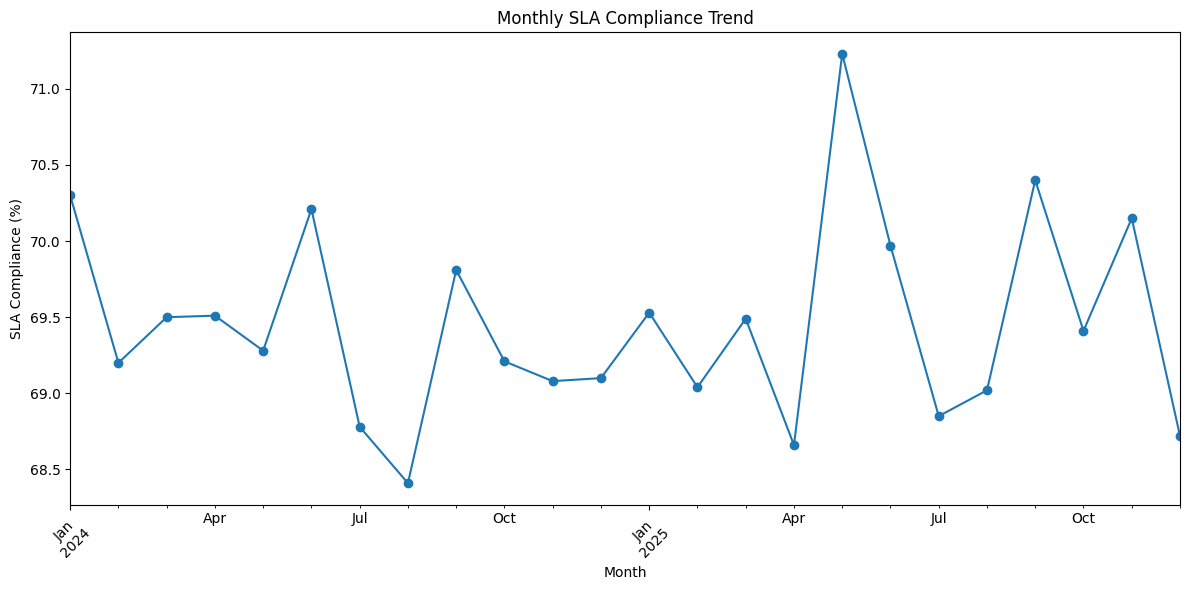

In [ ]:
#visualize monthly SLA performance trend
monthly_analysis["sla_compliance_pct"].plot(
    kind="line",
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly SLA Compliance Trend")
plt.xlabel("Month")
plt.ylabel("SLA Compliance (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#Analyze root causes
root_cause_analysis = (
    df.groupby("Root_Cause_Clean")
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          sla_breaches=("SLA_Breached", "sum"),
          avg_risk_score=("Risk_Score", "mean"),
          escalations=("Escalation_Flag", "sum")
      )
      .round(2)
)

root_cause_analysis["sla_compliance_pct"] = (
    (1 - root_cause_analysis["sla_breaches"] /
     root_cause_analysis["total_tickets"]) * 100
).round(2)

root_cause_analysis.sort_values(
    "sla_compliance_pct"
)

,total_tickets,avg_resolution_hours,sla_breaches,avg_risk_score,escalations,sla_compliance_pct
Root_Cause_Clean,,,,,,
Missing Data,12307,46.73,3851,42.23,2112,68.71
Unknown,13515,46.34,4183,42.10,2285,69.05
Human Error,12209,46.09,3775,42.25,2048,69.08
Process Gap,12522,46.27,3831,41.91,2118,69.41
Integration Failure,12236,45.73,3727,42.04,2071,69.54
External Dependency,12468,45.66,3771,41.77,2049,69.75
System Defect,12449,45.01,3764,41.98,2136,69.76
Training Gap,12294,45.66,3644,41.64,2041,70.36


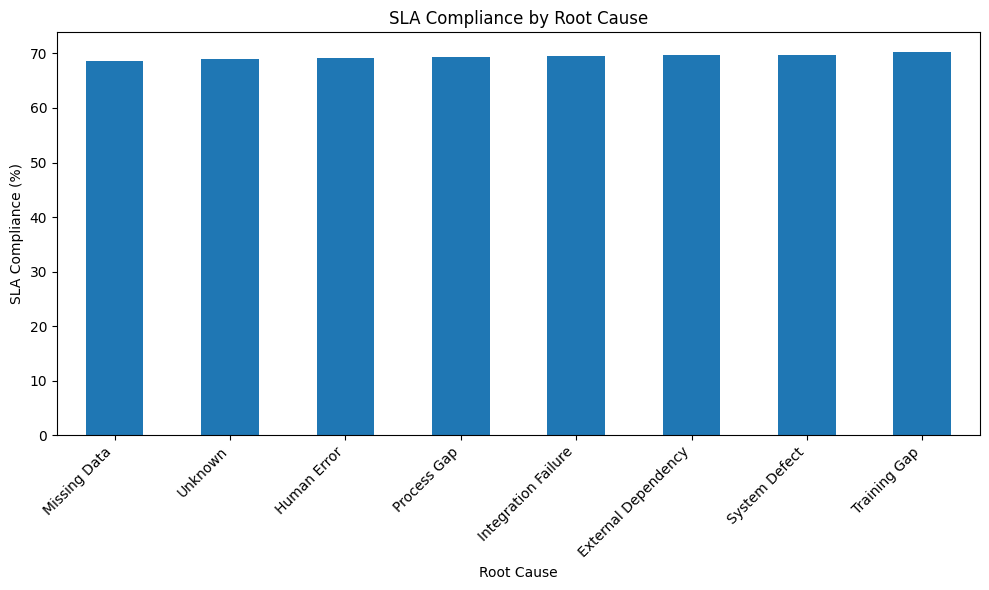

In [ ]:
#visualize rootcause SLA performance
root_cause_analysis.sort_values(
    "sla_compliance_pct"
)["sla_compliance_pct"].plot(
    kind="bar",
    figsize=(10, 6),
    legend=False
)

plt.title("SLA Compliance by Root Cause")
plt.xlabel("Root Cause")
plt.ylabel("SLA Compliance (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
#Find the top operational hotspots
# Mapping tables from our project dataset
process_map = {
    1: "Order Management",
    2: "Quality Review",
    3: "Inventory Planning",
    4: "Production Support",
    5: "Submission Management",
    6: "System Access",
    7: "Invoice Processing",
    8: "Customer Support"
}

df["Business_Unit"] = df["Business_Unit_ID"].map(business_unit_map)
df["Process"] = df["Process_ID"].map(process_map)

hotspots = (
    df.groupby(["Business_Unit", "Process"])
      .agg(
          total_tickets=("Ticket_ID", "count"),
          avg_resolution_hours=("Resolution_Hours", "mean"),
          sla_breaches=("SLA_Breached", "sum"),
          avg_risk_score=("Risk_Score", "mean"),
          escalations=("Escalation_Flag", "sum")
      )
      .round(2)
)

hotspots["sla_compliance_pct"] = (
    (1 - hotspots["sla_breaches"] /
     hotspots["total_tickets"]) * 100
).round(2)

hotspots = hotspots.reset_index().sort_values(
    ["sla_compliance_pct", "avg_resolution_hours"],
    ascending=[True, False]
)

hotspots.head(10)

,Business_Unit,Process,total_tickets,avg_resolution_hours,sla_breaches,avg_risk_score,escalations,sla_compliance_pct
60,Supply Chain,Production Support,1611,49.33,533,42.74,284,66.91
46,Quality Assurance,Submission Management,1598,46.40,526,42.91,297,67.08
55,Regulatory Affairs,System Access,1613,45.83,528,43.05,277,67.27
15,Customer Operations,System Access,1612,47.04,526,42.23,304,67.37
43,Quality Assurance,Order Management,1579,48.39,513,42.41,273,67.51
51,Regulatory Affairs,Order Management,1586,48.15,514,42.12,277,67.59
11,Customer Operations,Order Management,1528,46.31,494,42.91,284,67.67
41,Quality Assurance,Inventory Planning,1633,47.38,521,42.23,286,68.10
48,Regulatory Affairs,Customer Support,1560,46.98,497,42.05,289,68.14
47,Quality Assurance,System Access,1580,45.91,503,42.55,279,68.16


In [ ]:
#correlation analysis
correlation_matrix = df[
    [
        "Resolution_Hours",
        "SLA_Hours",
        "Risk_Score"
    ]
].corr().round(2)

correlation_matrix

,Resolution_Hours,SLA_Hours,Risk_Score
Resolution_Hours,1.00,0.24,0.10
SLA_Hours,0.24,1.00,-0.72
Risk_Score,0.10,-0.72,1.00


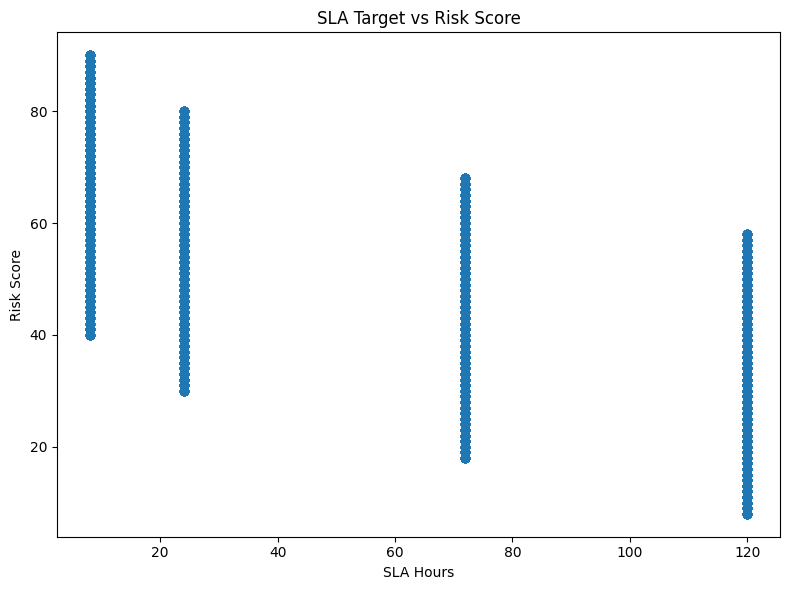

In [ ]:
#SLA Hours ↔ Risk Score visualisation
plt.figure(figsize=(8, 6))

plt.scatter(
    df["SLA_Hours"],
    df["Risk_Score"],
    alpha=0.15
)

plt.title("SLA Target vs Risk Score")
plt.xlabel("SLA Hours")
plt.ylabel("Risk Score")

plt.tight_layout()
plt.show()

In [ ]:
#identify the most important KPIs
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Average Resolution Hours",
        "SLA Compliance",
        "SLA Breach Rate",
        "Average Risk Score",
        "Escalated Tickets",
        "Escalation Rate"
    ],
    "Value": [
        len(df),
        round(df["Resolution_Hours"].mean(), 2),
        round((~df["SLA_Breached"]).mean() * 100, 2),
        round(df["SLA_Breached"].mean() * 100, 2),
        round(df["Risk_Score"].mean(), 2),
        int(df["Escalation_Flag"].sum()),
        round(df["Escalation_Flag"].mean() * 100, 2)
    ]
})

kpi_summary

,Metric,Value
0,Total Tickets,100000.00
1,Average Resolution Hours,45.94
2,SLA Compliance,69.45
3,SLA Breach Rate,30.55
4,Average Risk Score,41.99
5,Escalated Tickets,16860.00
6,Escalation Rate,16.86


In [ ]:
#dataset for Power BI
df.to_csv("enterprise_operations_risk_analytics_clean.csv", index=False)

print("Cleaned dataset exported successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Cleaned dataset exported successfully!
Rows: 100000
Columns: 20
